#  Residual EDA

This notebook compares the residual structure of the model against the day-ahead naive benchmark. The goal is not final outlier selection yet, but to understand the structure of the residuals.


In [35]:
# =========================================================
# 0. IMPORTS
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from arch import arch_model
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
# =========================================================
# 1. GLOBAL SETTINGS
# =========================================================

# time resolution and target variable
time_resolution = "qh"   # "qh" or "h"
target_col = "id1"       # "id1" or "id3"
model = "nn"             # "lgb", "xgb", or "nn"

# anomaly settings
IF_TOP_Q = 0.99
MAD_THRESHOLD = 3.5
IQR_MULTIPLIER = 1.5
IF_N_ESTIMATORS = 300
IF_RANDOM_STATE = 42

# GARCH settings
GARCH_P = 1
GARCH_Q = 1
GARCH_DIST = "normal"

In [37]:
# =========================================================
# 2. PREDICTOR DEFINITIONS
# =========================================================

predictor_vars = [
    "day_ahead_price",
    "load_actual_mw",
    "load_delta",
    "wind_delta",
    "solar_delta",
    "import_delta",
    "export_delta",
    "net_import_total",
    "fossil_gas_mw",
    "biomass_mw",
    "hydro_run_of_river_and_poundage_mw",
    "hydro_water_reservoir_mw",
    "hydro_pumped_storage_mw",
    "solar_mw",
    "wind_onshore_mw",
    "outage_total_true",
    "ramp_outage",
]

lagged_fundamental_vars = [
    "load_delta",
    "wind_delta",
    "solar_delta",
    "net_import_total",
    "ramp_outage",
]

fundamental_lags = [1, 2]

time_features = [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "free_day",
]

In [38]:
# =========================================================
# 3. LOAD DATA
# =========================================================

df = pd.read_csv(
    f"../data/{model}_predictions_{time_resolution}.csv",
    parse_dates=["datetime"],
)

df["datetime"] = pd.to_datetime(df["datetime"], utc=True).dt.tz_convert("Europe/Vienna")
df = df.sort_values("datetime").reset_index(drop=True)
df = df.loc[:, ~df.columns.duplicated()].copy()

print("data loaded:", df.shape)
print("start:", df["datetime"].min())
print("end:  ", df["datetime"].max())


data loaded: (34944, 35)
start: 2025-01-01 00:00:00+01:00
end:   2025-12-31 23:45:00+01:00


In [39]:
# =========================================================
# 4. HELPER FUNCTIONS
# =========================================================

def pick_first_existing(df, candidates, required=True):
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise KeyError(f"None of these columns found: {candidates}")

    return None


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mad_scores(x):
    x = np.asarray(x, dtype=float)
    median = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - median))

    if mad == 0 or np.isnan(mad):
        return np.full_like(x, np.nan, dtype=float)

    return 0.6745 * (x - median) / mad


def mad_flags(x, threshold=MAD_THRESHOLD):
    scores = mad_scores(x)
    return np.abs(scores) > threshold, scores


def iqr_bounds(x, multiplier=IQR_MULTIPLIER):
    x = np.asarray(x, dtype=float)
    q1 = np.nanpercentile(x, 25)
    q3 = np.nanpercentile(x, 75)
    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    return lower, upper


def iqr_flags(x, multiplier=IQR_MULTIPLIER):
    x = np.asarray(x, dtype=float)
    lower, upper = iqr_bounds(x, multiplier)
    flags = (x < lower) | (x > upper)
    return flags, {"lower": lower, "upper": upper}


def fit_iforest_and_select_top_q(X, top_q=IF_TOP_Q, n_estimators=IF_N_ESTIMATORS, random_state=IF_RANDOM_STATE):
    X = pd.DataFrame(X).copy()
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination="auto",
        random_state=random_state,
        n_jobs=-1,
    )
    iso.fit(X)

    scores = -iso.score_samples(X)  # higher score means more anomalous
    threshold = np.nanquantile(scores, top_q)
    flags = scores >= threshold

    return flags, scores, threshold, iso


def garch_standardize(residuals, p=GARCH_P, q=GARCH_Q, dist=GARCH_DIST):
    residuals = np.asarray(residuals, dtype=float)
    idx_valid = np.isfinite(residuals)

    resid = pd.Series(residuals).replace([np.inf, -np.inf], np.nan).dropna().values
    resid_centered = resid - np.nanmean(resid)

    garch = arch_model(
        resid_centered,
        mean="Zero",
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
    )

    fit = garch.fit(disp="off")
    cond_vol = np.asarray(fit.conditional_volatility)
    z = resid_centered / cond_vol

    out = np.full(len(residuals), np.nan, dtype=float)
    out[idx_valid] = z

    return out, cond_vol, fit


def build_if_features(df, residual_col, freeday_candidates=("free_day", "freeday")):
    free_day_col = pick_first_existing(df, list(freeday_candidates), required=False)

    out = pd.DataFrame(index=df.index)
    out["residual"] = df[residual_col].astype(float)
    out["hour_of_day"] = df["datetime"].dt.hour.astype(int)
    out["day_of_week"] = df["datetime"].dt.dayofweek.astype(int)

    if free_day_col is not None:
        out["free_day"] = df[free_day_col].astype(float)
    else:
        out["free_day"] = (df["datetime"].dt.dayofweek >= 5).astype(int)

    return out


def selection_metrics(mask_a, mask_b):
    mask_a = np.asarray(mask_a, dtype=bool)
    mask_b = np.asarray(mask_b, dtype=bool)

    n_a = int(mask_a.sum())
    n_b = int(mask_b.sum())
    overlap = int((mask_a & mask_b).sum())
    union = int((mask_a | mask_b).sum())

    return {
        "n_a": n_a,
        "n_b": n_b,
        "overlap_n": overlap,
        "overlap_rate_a": overlap / n_a if n_a > 0 else np.nan,
        "overlap_rate_b": overlap / n_b if n_b > 0 else np.nan,
        "jaccard": overlap / union if union > 0 else np.nan,
    }


def selected_error_summary(df, mask, abs_resid_col, prefix):
    mask = np.asarray(mask, dtype=bool)
    vals = df.loc[mask, abs_resid_col]

    return {
        f"{prefix}_n": int(mask.sum()),
        f"{prefix}_avg_abs_resid": float(vals.mean()) if len(vals) else np.nan,
        f"{prefix}_median_abs_resid": float(vals.median()) if len(vals) else np.nan,
        f"{prefix}_p95_abs_resid": float(vals.quantile(0.95)) if len(vals) else np.nan,
    }


def compare_two_selections(df, mask_naive, mask_model, abs_naive_col, abs_model_col, label):
    out = {"scenario": label}
    out.update(selection_metrics(mask_naive, mask_model))
    out.update(selected_error_summary(df, mask_naive, abs_naive_col, "naive_selected"))
    out.update(selected_error_summary(df, mask_model, abs_model_col, "model_selected"))
    return out


def evaluate_price_metrics(actual_price, pred_price):
    residuals = np.asarray(actual_price) - np.asarray(pred_price)
    abs_residuals = np.abs(residuals)

    return {
        "ResidualMean": np.mean(residuals),
        "MAE": mean_absolute_error(actual_price, pred_price),
        "RMSE": rmse(actual_price, pred_price),
        "R2": r2_score(actual_price, pred_price),
        "p95_abs_residual": np.percentile(abs_residuals, 95),
        "p99_abs_residual": np.percentile(abs_residuals, 99),
    }


def set_publication_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "figure.figsize": (10, 6),
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })


set_publication_style()


In [40]:
# =========================================================
# 5. PREPARE DATA FOR COMPARISON
# =========================================================

actual_col = pick_first_existing(df, [target_col.upper(), target_col])
pred_col = pick_first_existing(df, [f"{target_col.upper()}_hat", f"{target_col}_hat", "ID1_hat", "id1_hat"])
da_col = pick_first_existing(df, ["day_ahead_price", "DA_price", "da_price"])

work = df.copy()
work["actual_price"] = work[actual_col].astype(float)
work["model_price"] = work[pred_col].astype(float)
work["naive_price"] = work[da_col].astype(float)

# residual convention: actual - prediction
work["naive_resid"] = work["actual_price"] - work["naive_price"]
work["model_resid"] = work["actual_price"] - work["model_price"]
work["naive_abs_resid"] = work["naive_resid"].abs()
work["model_abs_resid"] = work["model_resid"].abs()

work = work.dropna(subset=["actual_price", "model_price", "naive_price"]).reset_index(drop=True)

work["naive_z"], naive_cond_vol, naive_garch_fit = garch_standardize(work["naive_resid"].values)
work["model_z"], model_cond_vol, model_garch_fit = garch_standardize(work["model_resid"].values)
work["naive_abs_z"] = np.abs(work["naive_z"])
work["model_abs_z"] = np.abs(work["model_z"])

work["hour_of_day"] = work["datetime"].dt.hour
work["day_of_week"] = work["datetime"].dt.dayofweek

print(work[["datetime", "actual_price", "model_price", "naive_price", "naive_abs_resid", "model_abs_resid"]].head())
print("\nrows used:", len(work))
print("naive MAE:", work["naive_abs_resid"].mean())
print("model MAE:", work["model_abs_resid"].mean())


                   datetime  actual_price  model_price  naive_price  \
0 2025-01-01 00:00:00+01:00      163.9200     153.7804     109.0000   
1 2025-01-01 00:15:00+01:00      244.3700     157.2852     109.0000   
2 2025-01-01 00:30:00+01:00      137.5500     153.0472     109.0000   
3 2025-01-01 00:45:00+01:00      147.5600     147.5650     109.0000   
4 2025-01-01 01:00:00+01:00      226.4600     160.9401      97.0300   

   naive_abs_resid  model_abs_resid  
0          54.9200          10.1396  
1         135.3700          87.0848  
2          28.5500          15.4972  
3          38.5600           0.0050  
4         129.4300          65.5199  

rows used: 34944
naive MAE: 31.226034226190478
model MAE: 28.042926145801147


In [41]:
# =========================================================
# 6. BASIC RESIDUAL SUMMARY
# =========================================================

summary_cols = ["naive_resid", "model_resid", "naive_z", "model_z"]
residual_summary = work[summary_cols].agg(["mean", "std", "skew", "kurt"])
residual_summary.loc["mean_abs"] = [
    work["naive_abs_resid"].mean(),
    work["model_abs_resid"].mean(),
    work["naive_abs_z"].mean(),
    work["model_abs_z"].mean(),
]

print(residual_summary.T)


               mean     std    skew     kurt  mean_abs
naive_resid  0.0824 66.3040 -1.2067 253.0121   31.2260
model_resid  2.4108 62.4609 -1.8796 306.2895   28.0429
naive_z     -0.0127  1.0253  0.0532  15.3868    0.7572
model_z     -0.0126  1.0250  0.4389  23.4879    0.7516


In [42]:
# =========================================================
# 7. PRICE-LEVEL METRICS
# =========================================================

metrics_df = pd.DataFrame([
    {"Model": "Naive", "Variant": "ID-DA", **evaluate_price_metrics(work["actual_price"], work["naive_price"])},
    {"Model": model.upper(), "Variant": "Model", **evaluate_price_metrics(work["actual_price"], work["model_price"])},
])

pd.options.display.float_format = "{:.4f}".format
print(metrics_df.to_string(index=False))


Model Variant  ResidualMean     MAE    RMSE     R2  p95_abs_residual  p99_abs_residual
Naive   ID-DA        0.0824 31.2260 66.3031 0.3565           91.6085          195.3409
   NN   Model        2.4108 28.0429 62.5066 0.4281           77.4854          180.4221


In [43]:
# =========================================================
# 8. ABSOLUTE RESIDUAL QUANTILES
# =========================================================

percentiles = [0.01, 0.05, 0.50, 0.95, 0.99]
quantile_df = pd.DataFrame({
    "naive_abs_resid": work["naive_abs_resid"].quantile(percentiles),
    "model_abs_resid": work["model_abs_resid"].quantile(percentiles),
})
quantile_df["improvement_pct"] = (1 - quantile_df["model_abs_resid"] / quantile_df["naive_abs_resid"]) * 100

print(quantile_df)


        naive_abs_resid  model_abs_resid  improvement_pct
0.0100           0.3000           0.3007          -0.2446
0.0500           1.5900           1.4686           7.6362
0.5000          18.8100          17.4518           7.2204
0.9500          91.6085          77.4854          15.4168
0.9900         195.3409         180.4221           7.6373


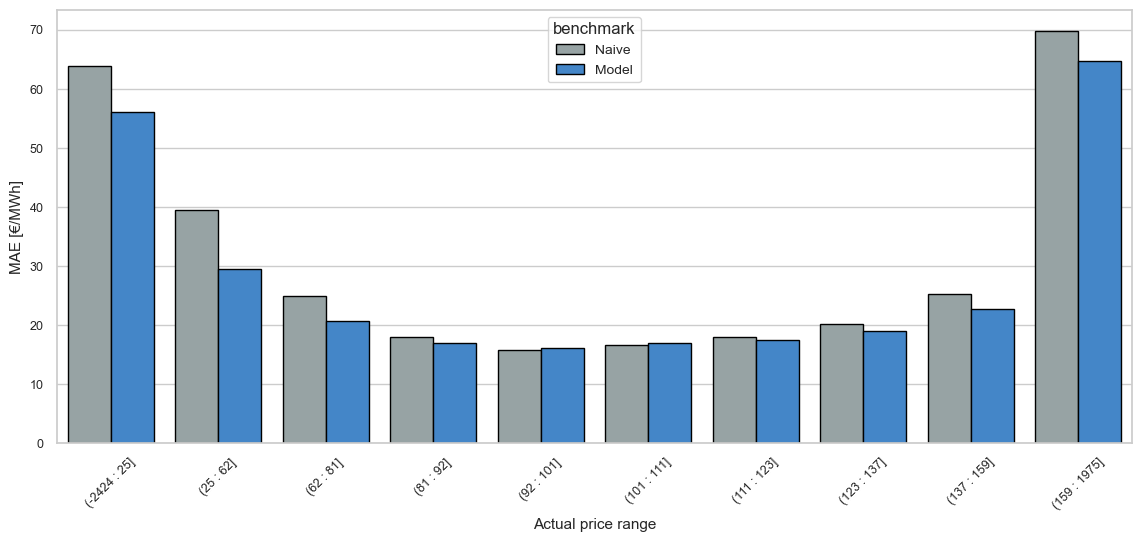

In [44]:
# =========================================================
# 9. ERROR BY PRICE QUANTILE
# =========================================================

plot_df = work.copy()
plot_df["price_bin"] = pd.qcut(plot_df["actual_price"], 10, duplicates="drop")

bin_analysis = (
    plot_df
    .groupby("price_bin", observed=True)[["naive_abs_resid", "model_abs_resid"]]
    .mean()
    .reset_index()
)

bin_analysis["price_range"] = bin_analysis["price_bin"].apply(
    lambda interval: f"({interval.left:.0f} : {interval.right:.0f}]"
)

plot_data = bin_analysis.melt(
    id_vars="price_range",
    value_vars=["naive_abs_resid", "model_abs_resid"],
    var_name="benchmark",
    value_name="MAE",
)
plot_data["benchmark"] = plot_data["benchmark"].replace({
    "naive_abs_resid": "Naive",
    "model_abs_resid": "Model",
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data, 
    x='price_range', 
    y='MAE', 
    hue='benchmark', 
    palette=['#95a5a6', '#2e86de'],
    edgecolor='black',    
    linewidth=1         
)

plt.rcParams.update({
    "font.size": 26,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,
})

#plt.title("Mean Absolute Error by Price Quantile")
plt.ylabel("MAE [€/MWh]")
plt.xlabel("Actual price range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

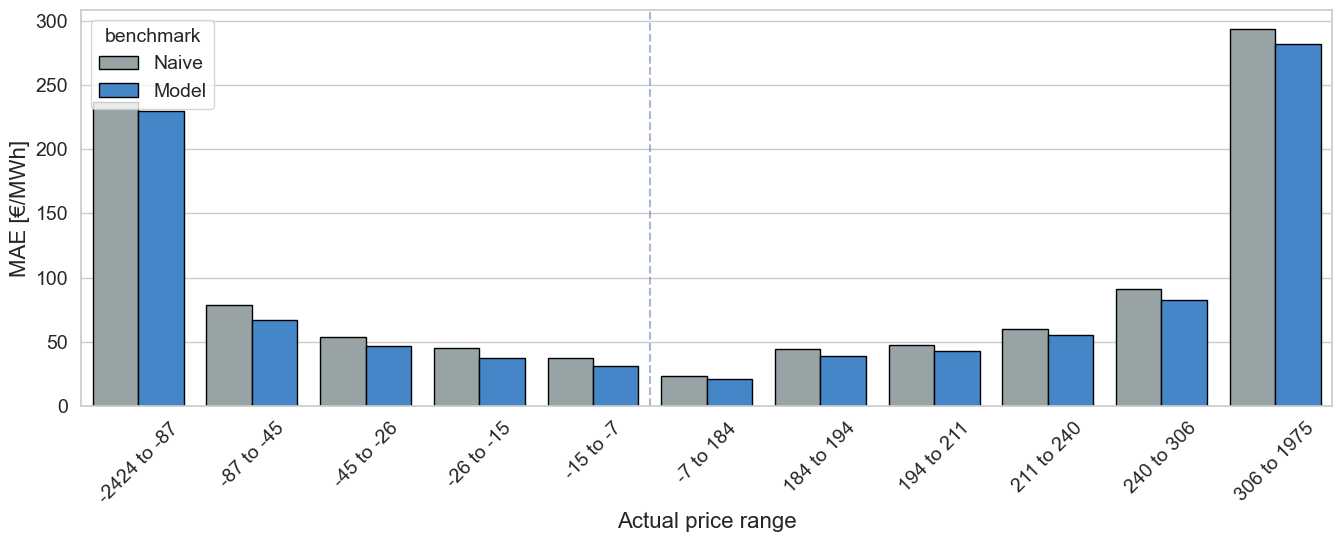

In [45]:
# =========================================================
# 10. ERROR IN PRICE TAILS
# =========================================================

tail_quantiles = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
bin_edges = work["actual_price"].quantile(tail_quantiles).drop_duplicates().values

plot_df = work.copy()
plot_df["tail_bin"] = pd.cut(plot_df["actual_price"], bins=bin_edges, include_lowest=True)

tail_analysis = (
    plot_df
    .dropna(subset=["tail_bin"])
    .groupby("tail_bin", observed=True)[["naive_abs_resid", "model_abs_resid"]]
    .mean()
    .reset_index()
)

tail_analysis["price_range"] = tail_analysis["tail_bin"].apply(
    lambda interval: f"{interval.left:.0f} to {interval.right:.0f}"
)

plot_tail_data = tail_analysis.melt(
    id_vars="price_range",
    value_vars=["naive_abs_resid", "model_abs_resid"],
    var_name="benchmark",
    value_name="MAE",
)
plot_tail_data["benchmark"] = plot_tail_data["benchmark"].replace({
    "naive_abs_resid": "Naive",
    "model_abs_resid": "Model",
})

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_tail_data, 
    x='price_range', 
    y='MAE', 
    hue='benchmark', 
    palette=['#95a5a6', '#2e86de'],
    edgecolor='black',    
    linewidth=1         
)

plt.rcParams.update({
    "font.size": 26,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,
})

plt.axvline(x=4.5, linestyle="--", alpha=0.5)
#plt.title("Mean Absolute Error in Lower and Upper Price Tails")
plt.ylabel("MAE [€/MWh]")
plt.xlabel("Actual price range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Error profile by hour

Compare the mean and 95th percentile of absolute residuals over the day.


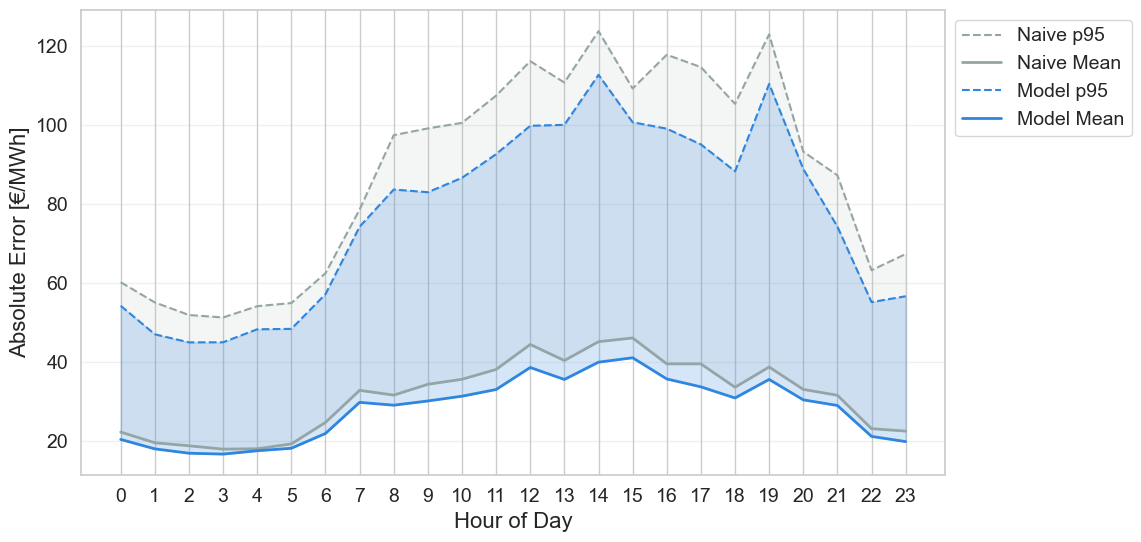

In [46]:
# =========================================================
# 11. ERROR PROFILE BY HOUR
# =========================================================

hourly_res = work.groupby("hour_of_day").agg(
    naive_p95=("naive_abs_resid", lambda x: np.percentile(x, 95)),
    model_p95=("model_abs_resid", lambda x: np.percentile(x, 95)),
    naive_mean=("naive_abs_resid", "mean"),
    model_mean=("model_abs_resid", "mean"),
)

plt.figure(figsize=(12, 6))
# --- Naive Benchmark (Grey) ---
plt.plot(hourly_res.index, hourly_res['naive_p95'], color='#95a5a6', 
         linestyle='--', linewidth=1.5, label='Naive p95')
plt.plot(hourly_res.index, hourly_res['naive_mean'], color='#95a5a6', 
         linewidth=2, label='Naive Mean')
plt.fill_between(hourly_res.index, hourly_res['naive_mean'], hourly_res['naive_p95'], 
                 color='#95a5a6', alpha=0.1)

# --- Expert Model (Blue) ---
plt.plot(hourly_res.index, hourly_res['model_p95'], color='#2e86de', 
         linestyle='--', linewidth=1.5, label='Model p95')
plt.plot(hourly_res.index, hourly_res['model_mean'], color='#2e86de', 
         linewidth=2, label='Model Mean')
plt.fill_between(hourly_res.index, hourly_res['model_mean'], hourly_res['model_p95'], 
                 color='#2e86de', alpha=0.2)

# Styling
#plt.title("Error Profile: Mean vs. p95")
plt.ylabel("Absolute Error [€/MWh]")
plt.xlabel("Hour of Day")
plt.xticks(range(0, 24))
plt.grid(True, axis='y', alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True) # legend outside plot

plt.tight_layout()
plt.show()

## Absolute performance gain per naive residual bin

The absolute residuals of the naive benchmark are grouped into 20 bins. For each bin the mean performance gain/loss of the model is plotted the naive mean absolute residual in that bin.

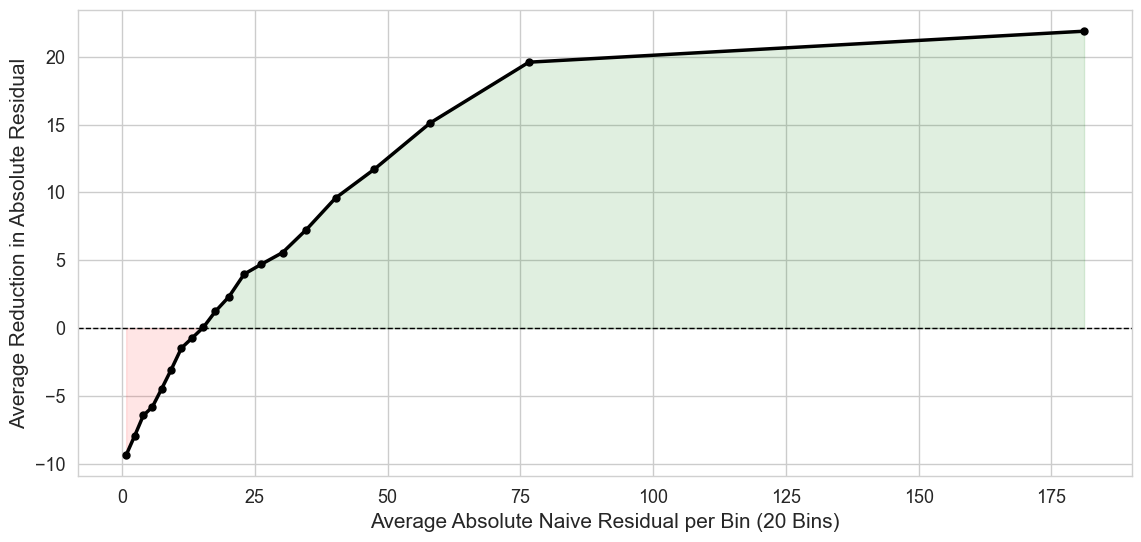

In [47]:
# =========================================================
# 12. ERROR REDUCTION BY NAIVE ERROR SIZE
# =========================================================

n_bins = 20

plot_df = work.copy()

plot_df["error_reduction"] = (
    plot_df["naive_abs_resid"] - plot_df["model_abs_resid"]
)

plot_df["naive_error_bin"] = pd.qcut(
    plot_df["naive_abs_resid"],
    q=n_bins,
    duplicates="drop"
)

bin_analysis = (
    plot_df
    .groupby("naive_error_bin", observed=True)
    .agg(
        naive_error_mean=("naive_abs_resid", "mean"),
        avg_error_reduction=("error_reduction", "mean"),
        observations=("error_reduction", "size"),
    )
    .reset_index()
)

x = bin_analysis["naive_error_mean"]
y = bin_analysis["avg_error_reduction"]

plt.figure(figsize=(12, 6))

# main line
plt.plot(
    x,
    y,
    marker="o",
    linewidth=2.5,
    color="black",
    markersize=5,
)

# green area
plt.fill_between(
    x,
    y,
    0,
    where=(y >= 0),
    interpolate=True,
    color="green",
    alpha=0.12,
)

# red area
plt.fill_between(
    x,
    y,
    0,
    where=(y < 0),
    interpolate=True,
    color="red",
    alpha=0.10,
)

# zero line
plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

# labels
plt.xlabel(
    f"Average Absolute Naive Residual per Bin ({n_bins} Bins)",
    fontsize=15,
)

plt.ylabel(
    "Average Reduction in Absolute Residual",
    fontsize=15,
)

# grey border
ax = plt.gca()

border_color = "#d0d0d0"

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(border_color)
    spine.set_linewidth(1.0)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()